# Stage 4 Sleep Stress Linear Models

Linear-family experiments for next-sleep average stress using the Stage 4 day-to-next-sleep modeling frame.


In [1]:
from pathlib import Path
import importlib
import os
import sys
import warnings

os.environ.setdefault("MPLBACKEND", "Agg")
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/wearable-analytics-matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn import exceptions as sklearn_exceptions

convergence_warning = getattr(sklearn_exceptions, "Convergence" + "Warning")
warnings.filterwarnings("ignore", category=convergence_warning)

repo_root = Path.cwd().resolve()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from garmin_analytics.modeling.stage4 import STAGE4_PRIMARY_TARGET, STAGE4_SPLIT_COLUMN, split_summary
import garmin_analytics.modeling.stage4_linear as stage4_linear

stage4_linear = importlib.reload(stage4_linear)
Stage4LinearConfig = stage4_linear.Stage4LinearConfig
Stage4LinearGridSpec = stage4_linear.Stage4LinearGridSpec
build_stage4_linear_candidate_grid = stage4_linear.build_stage4_linear_candidate_grid
build_stage4_linear_best_by_model_family_artifact = stage4_linear.build_stage4_linear_best_by_model_family_artifact
build_stage4_linear_experiment_plan = stage4_linear.build_stage4_linear_experiment_plan
build_stage4_linear_summary_markdown = stage4_linear.build_stage4_linear_summary_markdown
finalize_stage4_linear_modeling = stage4_linear.finalize_stage4_linear_modeling
format_stage4_linear_experiment_plan = stage4_linear.format_stage4_linear_experiment_plan
candidate_grid_frame = stage4_linear.candidate_grid_frame
compute_stage4_linear_feature_importance = stage4_linear.compute_stage4_linear_feature_importance
plot_stage4_linear_prediction_diagnostics = stage4_linear.plot_stage4_linear_prediction_diagnostics
plot_stage4_linear_rank1_feature_importance = stage4_linear.plot_stage4_linear_rank1_feature_importance
plot_stage4_linear_hyperparameter_diagnostics = stage4_linear.plot_stage4_linear_hyperparameter_diagnostics
plot_stage4_linear_factor_comparisons = stage4_linear.plot_stage4_linear_factor_comparisons
plot_stage4_linear_finalist_metric_comparison = stage4_linear.plot_stage4_linear_finalist_metric_comparison
plot_stage4_linear_validation_diagnostics = stage4_linear.plot_stage4_linear_validation_diagnostics
resolve_stage4_feature_columns = stage4_linear.resolve_stage4_feature_columns
run_stage4_linear_modeling = stage4_linear.run_stage4_linear_modeling
stage4_linear_grid_spec_from_preset = stage4_linear.stage4_linear_grid_spec_from_preset
stage4_linear_experiment_budget_issues = stage4_linear.stage4_linear_experiment_budget_issues
stage4_linear_candidate_from_record = stage4_linear.stage4_linear_candidate_from_record
tune_stage4_linear_modeling = stage4_linear.tune_stage4_linear_modeling

frame_path = repo_root / "data" / "processed" / "stage4_sleep_modeling_frame.parquet"
feature_catalog_path = repo_root / "reports" / "stage4_sleep_modeling_feature_sets.csv"
summary_path = repo_root / "reports" / "stage4_sleep_stress_linear_models_summary.md"
leaderboard_path = repo_root / "reports" / "stage4_sleep_stress_linear_model_leaderboard.csv"
grid_path = repo_root / "reports" / "stage4_sleep_stress_linear_model_grid.csv"
diagnostic_figure_path = repo_root / "docs" / "img" / "stage4_linear_prediction_diagnostics.png"
feature_importance_path = repo_root / "reports" / "stage4_sleep_stress_linear_rank1_feature_importance.csv"
feature_importance_figure_path = repo_root / "docs" / "img" / "stage4_linear_feature_importance.png"
best_by_model_family_path = repo_root / "reports" / "stage4_sleep_stress_linear_best_by_model_family.csv"
for required_path in [frame_path, feature_catalog_path]:
    if not required_path.exists():
        raise FileNotFoundError(required_path)

print("repo_root:", repo_root)


repo_root: /Users/abatrakov/Documents/FUN/wearable-analytics


## Control Panel

The saved outputs in this notebook come from an expanded linear-family grid run. For a quick local rerun, switch the control panel to the `smoke` or `standard` preset before executing the notebook end-to-end.

The expanded run is intentionally expensive. Read the saved outputs as a frozen analytical report; `Run All` is controlled by the settings below and is not intended to always reproduce the full heavy run quickly.

Choose `GRID_SOURCE = "preset"` to use a named preset exactly, or `GRID_SOURCE = "control_panel"` to build the grid only from the visible settings below. The default rerun path uses the `smoke` preset; the expanded saved run used the control-panel grid.


In [2]:
TARGET_COL = STAGE4_PRIMARY_TARGET
FEATURE_SET = "monitoring_full_wake_pre_sleep"
INCLUDE_SCHEDULE_CONTEXT = True
GRID_SOURCE = "preset"  # preset, control_panel
GRID_PRESET = "smoke"  # smoke, standard, heavy; used only when GRID_SOURCE == "preset"
TUNING_METRIC = "mae"
REPEATED_HOLDOUT_REPEATS = 3
REPEATED_HOLDOUT_SEED = 42
FINALIST_COUNT = 50
TOP_CANDIDATES_PER_MODEL_FAMILY = 5
N_JOBS = 8
PARALLEL_BACKEND = "loky"
PARALLEL_BATCH_SIZE = "auto"
ALLOW_LARGE_GRID_RUN = False
MAX_CANDIDATES_WITHOUT_CONFIRMATION = 30_000
MAX_APPROXIMATE_TUNING_FITS_WITHOUT_CONFIRMATION = 150_000

ENABLED_MODEL_FAMILIES = {
    "linear": True,
    "ridge": True,
    "lasso": True,
    "elastic_net": True,
    "huber": True,
    "pls": True,
}

ENABLED_FEATURE_SELECTION_MODES = {
    "none": True,
    "top_spearman": True,
    "top_mutual_info": True,
    "correlation_prune": True,
    "spearman_then_correlation": True,
    "lasso_nonzero": True,
}

TOP_K_VALUES = [40, 50, 60, 70, 80, 90, 100]
MIN_FEATURES = 8
MIN_ABS_SPEARMAN_VALUES = [0.0]
MIN_MUTUAL_INFO_VALUES = [0.0]
CORRELATION_THRESHOLDS = [0.90, 0.95, 0.99]
LASSO_SELECTOR_ALPHAS = [0.01, 0.03, 0.1]
LASSO_SELECTOR_MAX_ITER = 50_000

AVAILABLE_ROBUST_CLIPS = ["none", "z=4", "z=5"]
ROBUST_CLIPS = ["none", "z=4", "z=5"]

AVAILABLE_CALIBRATIONS = ["none", "linear"]
CALIBRATIONS = ["none", "linear"]

AVAILABLE_TARGET_TRANSFORMS = ["none", "log1p"]
TARGET_TRANSFORMS = ["none"]

AVAILABLE_PREDICTION_CLIPS = ["0_100", "none"]
PREDICTION_CLIPS = ["0_100"]

RIDGE_ALPHAS = [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0, 30.0, 100.0, 300.0, 1000.0]
LASSO_ALPHAS = [0.0001, 0.0003, 0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0]
ELASTIC_NET_ALPHAS = [0.0001, 0.0003, 0.001, 0.003, 0.010, 0.030, 0.100, 0.300, 1.000, 3.000]
ELASTIC_NET_L1_RATIOS = [0.01, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]
HUBER_ALPHAS = [0.0001, 0.0003, 0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0, 30.0, 100.0]
HUBER_EPSILONS = [1.05, 1.1, 1.15, 1.2, 1.3, 1.4, 1.5, 1.75, 2.0]
PLS_COMPONENTS = [1, 2, 3, 5, 8, 10, 15, 20]
FIT_INTERCEPT = True
MODEL_MAX_ITER = 500_000
MODEL_TOL = 1e-4

CALIBRATION_CV_FOLDS = 5
CALIBRATION_MIN_ROWS = 50


## Data Snapshot


In [3]:
frame = pd.read_parquet(frame_path)
feature_catalog = pd.read_csv(feature_catalog_path)

display(
    pd.DataFrame(
        [
            {
                "rows": len(frame),
                "columns": frame.shape[1],
                "start_date": pd.to_datetime(frame["calendarDate"]).min().date(),
                "end_date": pd.to_datetime(frame["calendarDate"]).max().date(),
                "target_available": int(pd.to_numeric(frame[TARGET_COL], errors="coerce").notna().sum()),
            }
        ]
    )
)
display(split_summary(frame))
display(
    feature_catalog.groupby("feature_set", as_index=False)
    .agg(features=("feature", "nunique"), median_missing_pct=("modeling_missing_pct", "median"))
    .sort_values("feature_set")
)


,rows,columns,start_date,end_date,target_available
0,589,295,2023-05-27,2026-05-18,524


,split,rows,eligible_rows,primary_target_rows,start_date,end_date
0,train,330,330,330,2023-05-27,2026-01-28
1,valid,71,71,71,2023-06-12,2026-01-20
2,test,71,71,71,2026-01-29,2026-05-13
3,not_eligible_or_missing_target,117,0,52,2023-07-10,2026-05-18


,feature_set,features,median_missing_pct
0,aggregate_plus_monitoring_full,138,0.0
1,aggregate_stage3_baseline,33,0.0
2,monitoring_core_wake_pre_sleep,56,0.0
3,monitoring_full_wake_pre_sleep,123,0.0


## Grid Audit


In [4]:
enabled_model_kinds = tuple(kind for kind, enabled in ENABLED_MODEL_FAMILIES.items() if enabled)
enabled_feature_selection_modes = tuple(
    mode for mode, enabled in ENABLED_FEATURE_SELECTION_MODES.items() if enabled
)

if GRID_SOURCE not in {"preset", "control_panel"}:
    raise ValueError("GRID_SOURCE must be 'preset' or 'control_panel'")

config = Stage4LinearConfig(
    target_col=TARGET_COL,
    feature_set=FEATURE_SET,
    grid_source=GRID_SOURCE,
    grid_preset=GRID_PRESET,
    include_schedule_context=INCLUDE_SCHEDULE_CONTEXT,
    repeated_holdout_repeats=REPEATED_HOLDOUT_REPEATS,
    repeated_holdout_seed=REPEATED_HOLDOUT_SEED,
    tuning_metric=TUNING_METRIC,
    calibration_cv_folds=CALIBRATION_CV_FOLDS,
    calibration_min_rows=CALIBRATION_MIN_ROWS,
    finalist_count=FINALIST_COUNT,
    n_jobs=N_JOBS,
    parallel_backend=PARALLEL_BACKEND,
    parallel_batch_size=PARALLEL_BATCH_SIZE,
)

if GRID_SOURCE == "preset":
    grid_spec = stage4_linear_grid_spec_from_preset(GRID_PRESET)
else:
    grid_spec = Stage4LinearGridSpec(
        preset="control_panel",
        model_kinds=enabled_model_kinds,
        feature_selection_modes=enabled_feature_selection_modes,
        top_k_values=tuple(TOP_K_VALUES),
        min_features=MIN_FEATURES,
        min_abs_spearman_values=tuple(MIN_ABS_SPEARMAN_VALUES),
        min_mutual_info_values=tuple(MIN_MUTUAL_INFO_VALUES),
        correlation_thresholds=tuple(CORRELATION_THRESHOLDS),
        lasso_selector_alphas=tuple(LASSO_SELECTOR_ALPHAS),
        lasso_selector_max_iter=LASSO_SELECTOR_MAX_ITER,
        robust_clips=tuple(ROBUST_CLIPS),
        calibrations=tuple(CALIBRATIONS),
        target_transforms=tuple(TARGET_TRANSFORMS),
        prediction_clips=tuple(PREDICTION_CLIPS),
        ridge_alphas=tuple(RIDGE_ALPHAS),
        lasso_alphas=tuple(LASSO_ALPHAS),
        elastic_net_alphas=tuple(ELASTIC_NET_ALPHAS),
        elastic_net_l1_ratios=tuple(ELASTIC_NET_L1_RATIOS),
        huber_alphas=tuple(HUBER_ALPHAS),
        huber_epsilons=tuple(HUBER_EPSILONS),
        pls_components=tuple(PLS_COMPONENTS),
        fit_intercept=FIT_INTERCEPT,
        max_iter=MODEL_MAX_ITER,
        tol=MODEL_TOL,
    )

feature_columns = resolve_stage4_feature_columns(
    feature_catalog,
    feature_set=FEATURE_SET,
    include_schedule_context=INCLUDE_SCHEDULE_CONTEXT,
)
candidates = build_stage4_linear_candidate_grid(config, grid_spec)
grid_audit = candidate_grid_frame(candidates)
experiment_plan = build_stage4_linear_experiment_plan(
    config,
    candidates,
    feature_columns=feature_columns,
)
experiment_budget_issues = stage4_linear_experiment_budget_issues(
    experiment_plan,
    max_candidates=MAX_CANDIDATES_WITHOUT_CONFIRMATION,
    max_approximate_tuning_fits=MAX_APPROXIMATE_TUNING_FITS_WITHOUT_CONFIRMATION,
)

print(format_stage4_linear_experiment_plan(experiment_plan))
if experiment_budget_issues:
    print("\nTuning safety check: explicit confirmation required")
    for issue in experiment_budget_issues:
        print(f"  - {issue}")
    print("  Set ALLOW_LARGE_GRID_RUN = True only if this expanded run is intentional.")
else:
    print("\nTuning safety check: within configured budget")
display(
    grid_audit.groupby(["model_kind", "feature_selection_mode"], as_index=False)
    .size()
    .rename(columns={"size": "candidates"})
)


Experiment plan

Target:
  target_col: target_avgSleepStress_next_sleep

Feature set:
  feature_set: monitoring_full_wake_pre_sleep
  include_schedule_context: True
  candidate_features: 123

Grid source:
  grid_source: control_panel
  grid_preset: not used

Validation:
  metric: mae
  repeated_holdout_repeats: 3
  repeated_holdout_seed: 42

Enabled preprocessing:
  robust_clips: ['none', 'z=4', 'z=5']  count=3
  target_transforms: ['none']  count=1
  prediction_clips: ['0_100']  count=1
  calibrations: ['none', 'linear']  count=2
  calibration_cv_folds: 5

Feature selection:
  enabled modes:
    none: 1
    top_spearman: 7
    top_mutual_info: 7
    correlation_prune: 3
    spearman_then_correlation: 21
    lasso_nonzero: 3
  total feature selector configs: 42

Model configs:
  linear: 1
  ridge: 13
  lasso: 9
  elastic_net: 130
  huber: 117
  pls: 8
  total model configs: 278

Candidate count:
  preprocessing multiplier: 3
  feature selectors: 42
  model configs: 278
  calibration va

,model_kind,feature_selection_mode,candidates
0,elastic_net,correlation_prune,2340
1,elastic_net,lasso_nonzero,2340
2,elastic_net,none,780
3,elastic_net,spearman_then_correlation,16380
4,elastic_net,top_mutual_info,5460
5,elastic_net,top_spearman,5460
6,huber,correlation_prune,2106
7,huber,lasso_nonzero,2106
8,huber,none,702
9,huber,spearman_then_correlation,14742


## Tune Candidate Grid On Repeated Validation Holdouts


In [5]:
if "experiment_budget_issues" not in globals():
    raise RuntimeError("Run the Grid Audit cell before tuning.")
if experiment_budget_issues and not ALLOW_LARGE_GRID_RUN:
    details = "\n".join(f"- {issue}" for issue in experiment_budget_issues)
    raise RuntimeError(
        "Tuning was not started because the grid exceeds the configured safety budget.\n"
        f"{details}\n"
        "Reduce the control-panel grid or set ALLOW_LARGE_GRID_RUN = True for an intentional large run."
    )

if "tuning_result" in globals():
    del tuning_result
try:
    tuning_result = tune_stage4_linear_modeling(
        frame,
        feature_catalog,
        config=config,
        candidates=candidates,
    )
except Exception as exc:
    raise RuntimeError(
        "Candidate tuning failed before tuning_result was created. Fix the error above, then rerun this cell."
    ) from exc

print("Validation-only tuning complete. The reserved future test has not been evaluated.")
display(
    pd.DataFrame(
        [
            {
                "candidate_features": len(tuning_result.feature_columns),
                "candidate_grid": len(tuning_result.candidate_grid),
                "repeated_holdouts": config.repeated_holdout_repeats,
                "candidate_evaluations": len(tuning_result.tuning_repeats),
                "future_test_evaluated": False,
            }
        ]
    )
)


Validation-only tuning complete. The reserved future test has not been evaluated.


,candidate_features,candidate_grid,repeated_holdouts,candidate_evaluations,future_test_evaluated
0,123,70056,3,210168,False


## Validation Leaderboards


In [6]:
if "tuning_result" not in globals():
    raise RuntimeError(
        "tuning_result is unavailable. Run the Grid Audit cell, then complete the "
        "Tune Candidate Grid On Repeated Validation Holdouts cell before opening leaderboards."
    )

validation_cols = [
    "selection_rank",
    "candidate_short_label",
    "model_kind",
    "model_param_1",
    "model_param_2",
    "feature_selection_mode",
    "feature_selection_config_label",
    "feature_selection_param_1",
    "feature_selection_param_2",
    "robust_clip",
    "calibration",
    "target_transform",
    "prediction_clip",
    "mean_train_mae",
    "mean_train_rmse",
    "mean_train_r2",
    "mean_valid_mae",
    "std_valid_mae",
    "mean_valid_rmse",
    "mean_valid_r2",
    "mean_valid_spearman",
    "mean_selected_feature_count",
]

overall_validation = tuning_result.validation_slices["overall_validation"]
best_by_model = tuning_result.validation_slices["best_by_model_kind"]
best_by_model_selector = tuning_result.validation_slices["best_by_model_kind_feature_selection"]

display(overall_validation[validation_cols].head(25))
display(best_by_model[validation_cols])
display(best_by_model_selector[validation_cols].head(50))

display(
    tuning_result.validation_slices["dummy_validation"][
        [
            "model_kind",
            "mean_valid_mae",
            "std_valid_mae",
            "mean_valid_rmse",
            "mean_valid_r2",
        ]
    ]
)


,selection_rank,candidate_short_label,model_kind,model_param_1,model_param_2,feature_selection_mode,feature_selection_config_label,feature_selection_param_1,feature_selection_param_2,robust_clip,...,prediction_clip,mean_train_mae,mean_train_rmse,mean_train_r2,mean_valid_mae,std_valid_mae,mean_valid_rmse,mean_valid_r2,mean_valid_spearman,mean_selected_feature_count
0,1,Huber alpha=30 eps=1.15 | top_spearman_90 | cl...,huber,alpha=30,epsilon=1.15,top_spearman,top_spearman_90,top_k=90,min_features=8,z=4,...,0_100,3.572319,5.383315,0.411066,3.610268,0.395191,4.951843,0.350321,0.581085,90.000000
1,2,Huber alpha=30 eps=1.15 | top_spearman_90 | cl...,huber,alpha=30,epsilon=1.15,top_spearman,top_spearman_90,top_k=90,min_features=8,z=5,...,0_100,3.570981,5.361378,0.415858,3.611107,0.402253,4.958430,0.348270,0.581336,90.000000
2,3,Huber alpha=30 eps=1.1 | top_spearman_90 | cli...,huber,alpha=30,epsilon=1.1,top_spearman,top_spearman_90,top_k=90,min_features=8,z=4,...,0_100,3.566054,5.395350,0.408453,3.611797,0.398656,4.957789,0.349023,0.578368,90.000000
3,4,Huber alpha=30 eps=1.15 | spearman_then_correl...,huber,alpha=30,epsilon=1.15,spearman_then_correlation,spearman_then_correlation_90_corr0.99,top_k=90,corr=0.99,z=4,...,0_100,3.577576,5.389199,0.409791,3.613252,0.385117,4.950159,0.351017,0.579324,85.000000
4,5,Huber alpha=10 eps=1.15 | spearman_then_correl...,huber,alpha=10,epsilon=1.15,spearman_then_correlation,spearman_then_correlation_90_corr0.99,top_k=90,corr=0.99,z=4,...,0_100,3.485490,5.406151,0.406157,3.616021,0.424370,4.996974,0.341194,0.576937,85.000000
5,6,Huber alpha=30 eps=1.15 | spearman_then_correl...,huber,alpha=30,epsilon=1.15,spearman_then_correlation,spearman_then_correlation_90_corr0.99,top_k=90,corr=0.99,z=5,...,0_100,3.576022,5.367615,0.414510,3.616220,0.394015,4.955617,0.349240,0.579575,85.000000
6,7,Huber alpha=30 eps=1.1 | top_spearman_90 | cli...,huber,alpha=30,epsilon=1.1,top_spearman,top_spearman_90,top_k=90,min_features=8,z=5,...,0_100,3.565852,5.374298,0.413060,3.616261,0.402298,4.965933,0.346550,0.577619,90.000000
7,8,Huber alpha=30 eps=1.1 | spearman_then_correla...,huber,alpha=30,epsilon=1.1,spearman_then_correlation,spearman_then_correlation_90_corr0.99,top_k=90,corr=0.99,z=4,...,0_100,3.571002,5.399105,0.407652,3.616426,0.389833,4.956045,0.349627,0.577949,85.000000
8,9,Huber alpha=10 eps=1.2 | spearman_then_correla...,huber,alpha=10,epsilon=1.2,spearman_then_correlation,spearman_then_correlation_90_corr0.95,top_k=90,corr=0.95,z=4,...,0_100,3.509212,5.397598,0.408011,3.617389,0.405229,4.986241,0.344092,0.581431,68.333333
9,10,Huber alpha=10 eps=1.1 | spearman_then_correla...,huber,alpha=10,epsilon=1.1,spearman_then_correlation,spearman_then_correlation_90_corr0.99,top_k=90,corr=0.99,none,...,0_100,3.453270,5.349984,0.418609,3.618119,0.437591,5.006189,0.337992,0.576921,85.000000


,selection_rank,candidate_short_label,model_kind,model_param_1,model_param_2,feature_selection_mode,feature_selection_config_label,feature_selection_param_1,feature_selection_param_2,robust_clip,...,prediction_clip,mean_train_mae,mean_train_rmse,mean_train_r2,mean_valid_mae,std_valid_mae,mean_valid_rmse,mean_valid_r2,mean_valid_spearman,mean_selected_feature_count
0,1,Huber alpha=30 eps=1.15 | top_spearman_90 | cl...,huber,alpha=30,epsilon=1.15,top_spearman,top_spearman_90,top_k=90,min_features=8,z=4,...,0_100,3.572319,5.383315,0.411066,3.610268,0.395191,4.951843,0.350321,0.581085,90.000000
1,1648,Ridge alpha=300 | top_spearman_90 | clip=z=4,ridge,alpha=300,,top_spearman,top_spearman_90,top_k=90,min_features=8,z=4,...,0_100,3.756037,5.281373,0.433023,3.724539,0.343503,4.987544,0.338537,0.571940,90.000000
2,1776,ElasticNet alpha=1 l1=0.01 | top_spearman_90 |...,elastic_net,alpha=1,l1_ratio=0.01,top_spearman,top_spearman_90,top_k=90,min_features=8,z=4,...,0_100,3.765062,5.286845,0.431798,3.727971,0.338887,4.993029,0.336659,0.573735,90.000000
3,2004,PLS k=2 | lasso_nonzero_0.1 | clip=z=4 | cal=l...,pls,n_components=2,,lasso_nonzero,lasso_nonzero_0.1,alpha=0.1,min_features=8,z=4,...,0_100,3.813844,5.447306,0.396671,3.732696,0.310493,5.008860,0.333489,0.563819,46.666667
4,3814,Lasso alpha=1 | spearman_then_correlation_60_c...,lasso,alpha=1,,spearman_then_correlation,spearman_then_correlation_60_corr0.9,top_k=60,corr=0.9,z=4,...,0_100,4.026978,5.681752,0.343673,3.763576,0.281321,5.120085,0.305858,0.554659,32.666667
5,17467,Linear | spearman_then_correlation_60_corr0.9 ...,linear,,,spearman_then_correlation,spearman_then_correlation_60_corr0.9,top_k=60,corr=0.9,none,...,0_100,3.735077,5.334118,0.421379,3.872153,0.363892,5.233995,0.273960,0.526852,32.666667


,selection_rank,candidate_short_label,model_kind,model_param_1,model_param_2,feature_selection_mode,feature_selection_config_label,feature_selection_param_1,feature_selection_param_2,robust_clip,...,prediction_clip,mean_train_mae,mean_train_rmse,mean_train_r2,mean_valid_mae,std_valid_mae,mean_valid_rmse,mean_valid_r2,mean_valid_spearman,mean_selected_feature_count
0,1,Huber alpha=30 eps=1.15 | top_spearman_90 | cl...,huber,alpha=30,epsilon=1.15,top_spearman,top_spearman_90,top_k=90,min_features=8,z=4,...,0_100,3.572319,5.383315,0.411066,3.610268,0.395191,4.951843,0.350321,0.581085,90.000000
1,4,Huber alpha=30 eps=1.15 | spearman_then_correl...,huber,alpha=30,epsilon=1.15,spearman_then_correlation,spearman_then_correlation_90_corr0.99,top_k=90,corr=0.99,z=4,...,0_100,3.577576,5.389199,0.409791,3.613252,0.385117,4.950159,0.351017,0.579324,85.000000
2,1486,Huber alpha=100 eps=1.1 | none | clip=none | c...,huber,alpha=100,epsilon=1.1,none,none,,,none,...,0_100,3.620842,5.394954,0.408525,3.720385,0.327395,5.007575,0.331728,0.570811,123.000000
3,1610,Huber alpha=100 eps=1.1 | correlation_prune_0....,huber,alpha=100,epsilon=1.1,correlation_prune,correlation_prune_0.99,corr=0.99,min_features=8,none,...,0_100,3.633258,5.411104,0.404987,3.723605,0.332452,4.994264,0.335483,0.573695,117.000000
4,1648,Ridge alpha=300 | top_spearman_90 | clip=z=4,ridge,alpha=300,,top_spearman,top_spearman_90,top_k=90,min_features=8,z=4,...,0_100,3.756037,5.281373,0.433023,3.724539,0.343503,4.987544,0.338537,0.571940,90.000000
5,1666,Huber alpha=100 eps=1.05 | lasso_nonzero_0.1 |...,huber,alpha=100,epsilon=1.05,lasso_nonzero,lasso_nonzero_0.1,alpha=0.1,min_features=8,none,...,0_100,3.671693,5.369826,0.414087,3.724909,0.291515,4.984774,0.339064,0.571667,46.666667
6,1776,ElasticNet alpha=1 l1=0.01 | top_spearman_90 |...,elastic_net,alpha=1,l1_ratio=0.01,top_spearman,top_spearman_90,top_k=90,min_features=8,z=4,...,0_100,3.765062,5.286845,0.431798,3.727971,0.338887,4.993029,0.336659,0.573735,90.000000
7,1784,Ridge alpha=300 | spearman_then_correlation_90...,ridge,alpha=300,,spearman_then_correlation,spearman_then_correlation_90_corr0.99,top_k=90,corr=0.99,z=4,...,0_100,3.760598,5.299294,0.429188,3.728112,0.336104,4.982808,0.340188,0.571594,85.000000
8,1873,ElasticNet alpha=0.3 l1=0.01 | spearman_then_c...,elastic_net,alpha=0.3,l1_ratio=0.01,spearman_then_correlation,spearman_then_correlation_90_corr0.99,top_k=90,corr=0.99,z=4,...,0_100,3.691299,5.151415,0.460541,3.730063,0.339674,5.009717,0.334055,0.568553,85.000000
9,2004,PLS k=2 | lasso_nonzero_0.1 | clip=z=4 | cal=l...,pls,n_components=2,,lasso_nonzero,lasso_nonzero_0.1,alpha=0.1,min_features=8,z=4,...,0_100,3.813844,5.447306,0.396671,3.732696,0.310493,5.008860,0.333489,0.563819,46.666667


,model_kind,mean_valid_mae,std_valid_mae,mean_valid_rmse,mean_valid_r2
0,dummy_last,4.643991,0.518535,6.309677,-0.042142
1,dummy_median,4.665329,0.519702,6.208989,-0.008872
2,dummy_mean,4.734004,0.492040,6.244269,-0.021365


## Validation-Only Diagnostics Before Finalist Refit

These comparisons use repeated-holdout train/validation metrics only. The overall ranking is paired with a balanced top-per-model-family view, and optional grid dimensions are compared with matched-candidate deltas. The reserved future test remains unavailable until the explicit finalist-refit step below.


validation_mae_distribution


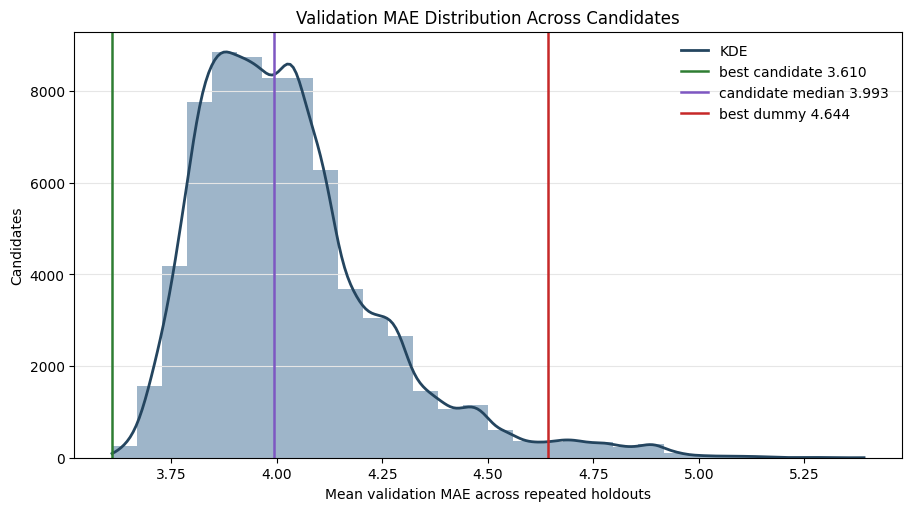

top_candidates


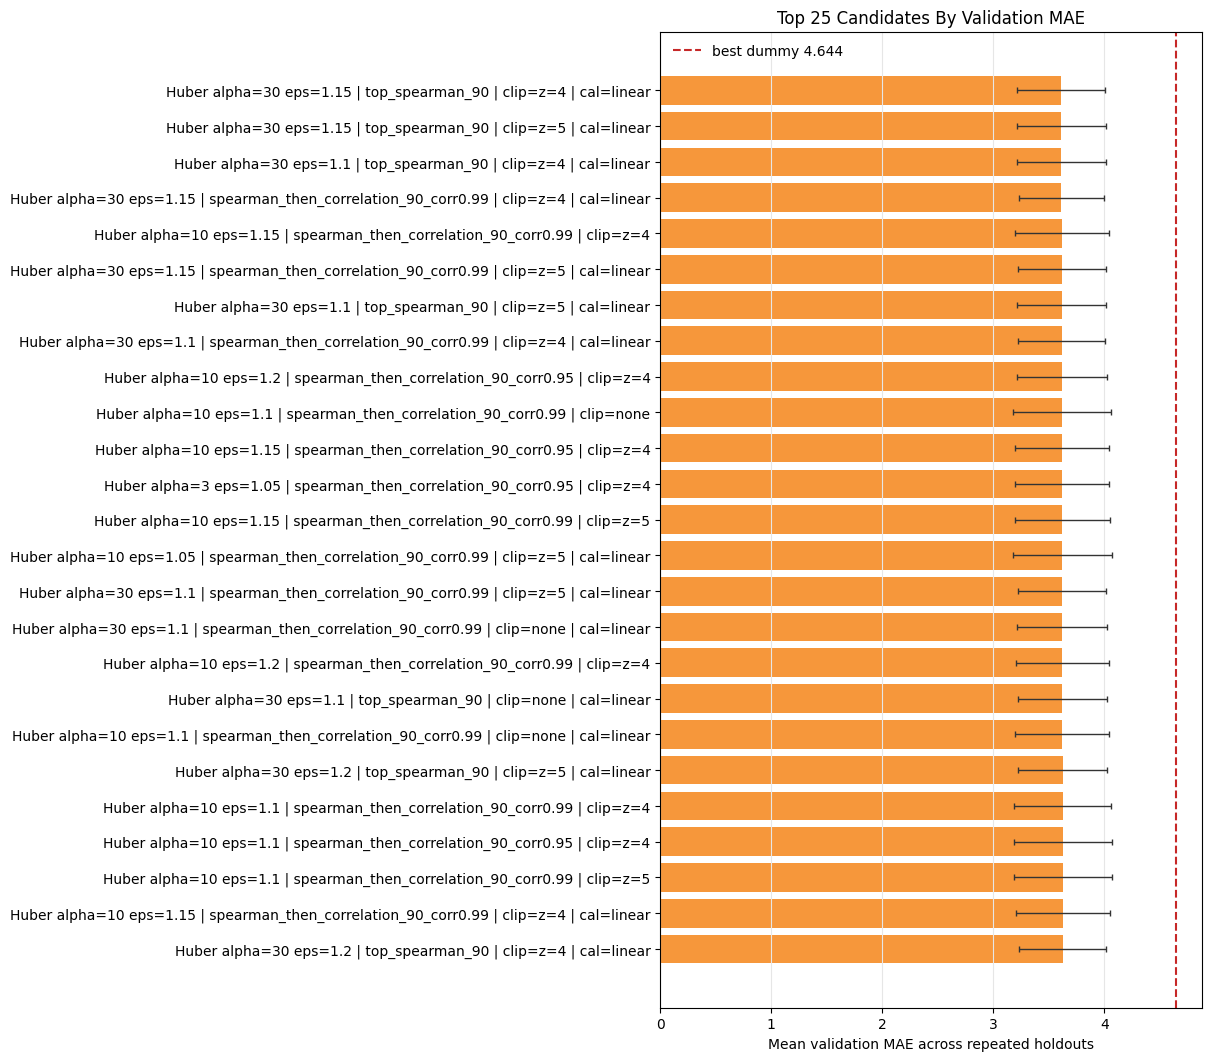

top_candidates_by_model_family


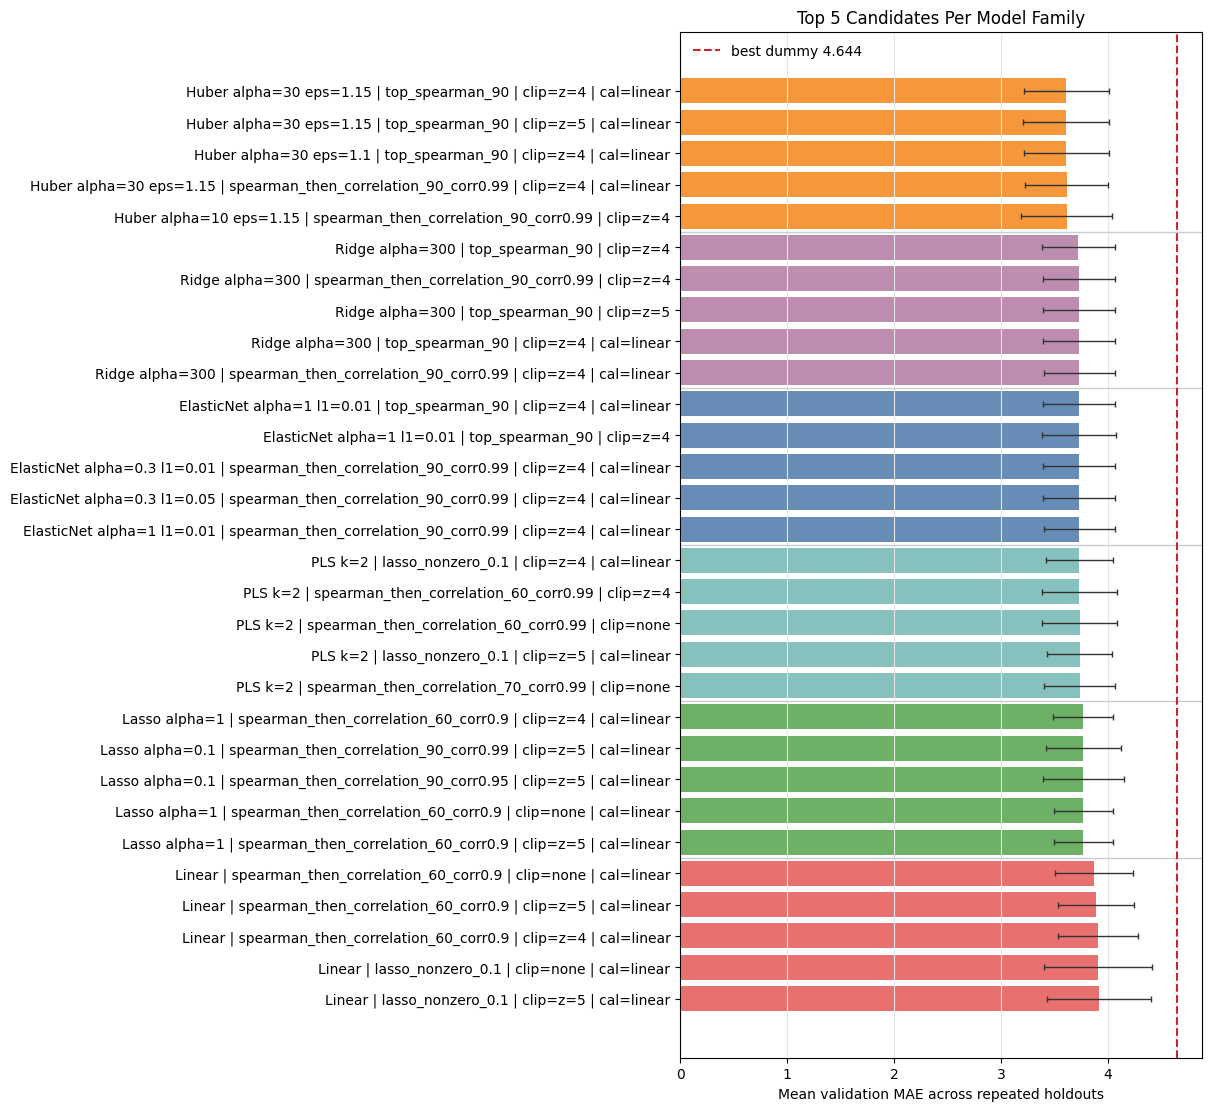

best_by_model_family


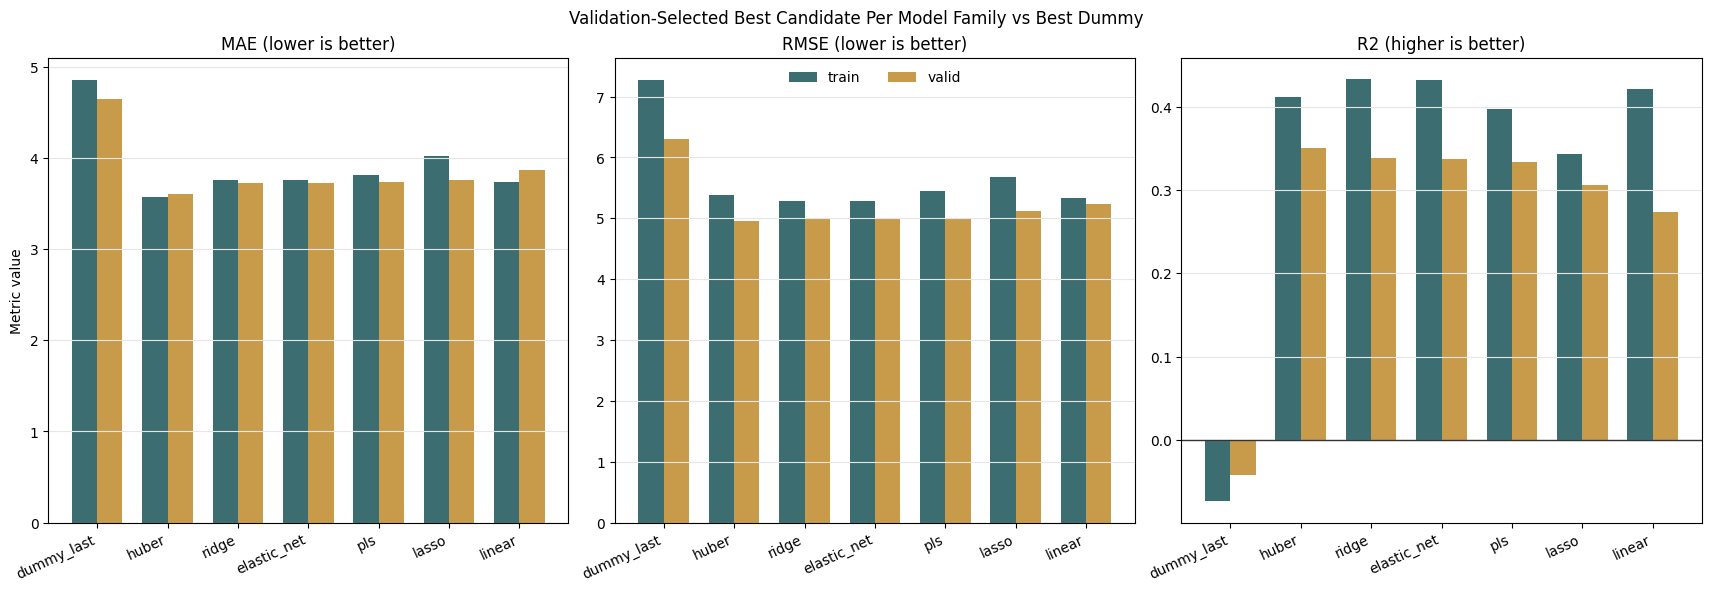

model_family_distribution


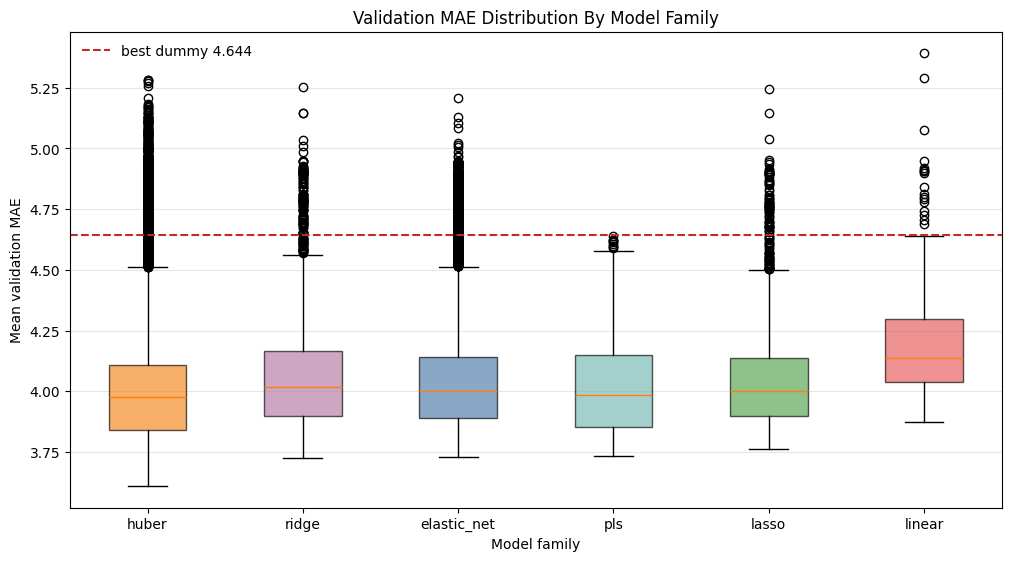

train_validation_gap


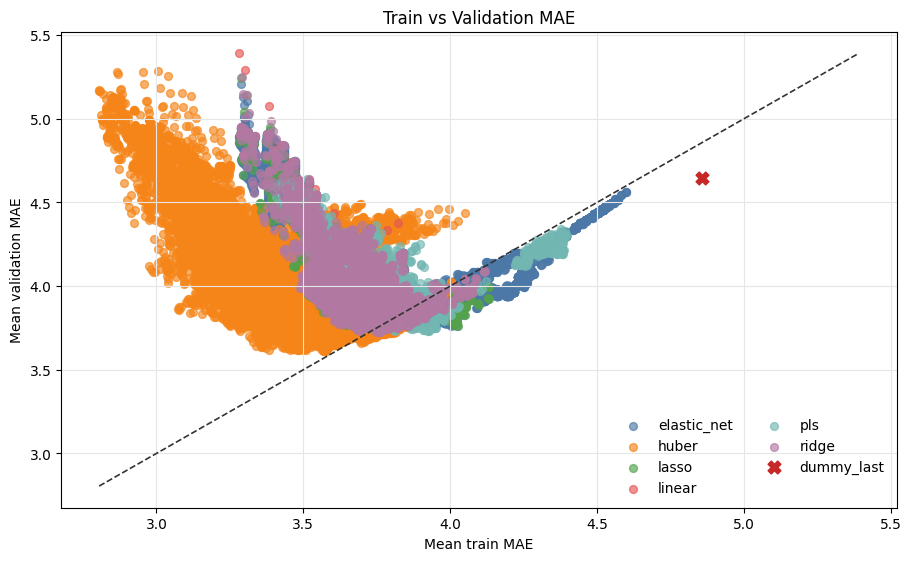

performance_stability


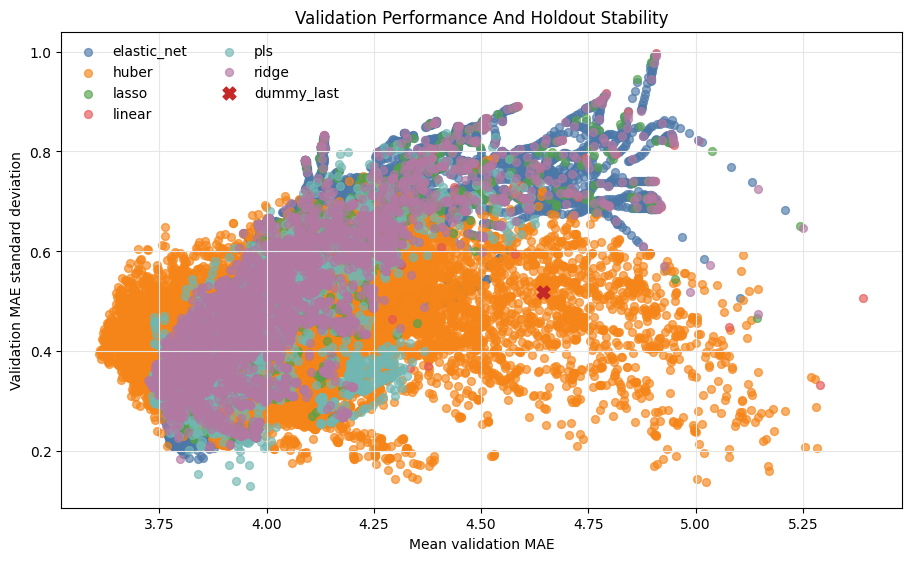

feature_count_tradeoff


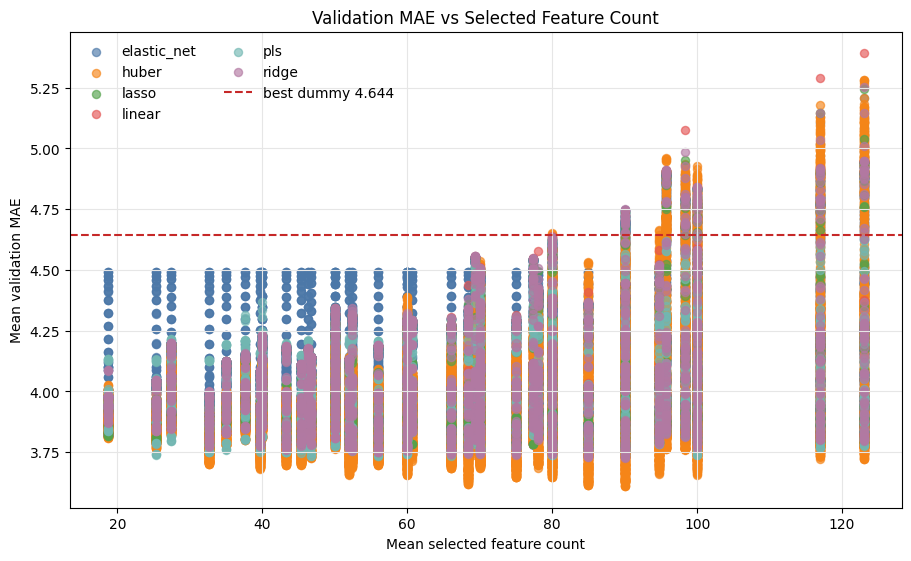

feature_selector_distribution


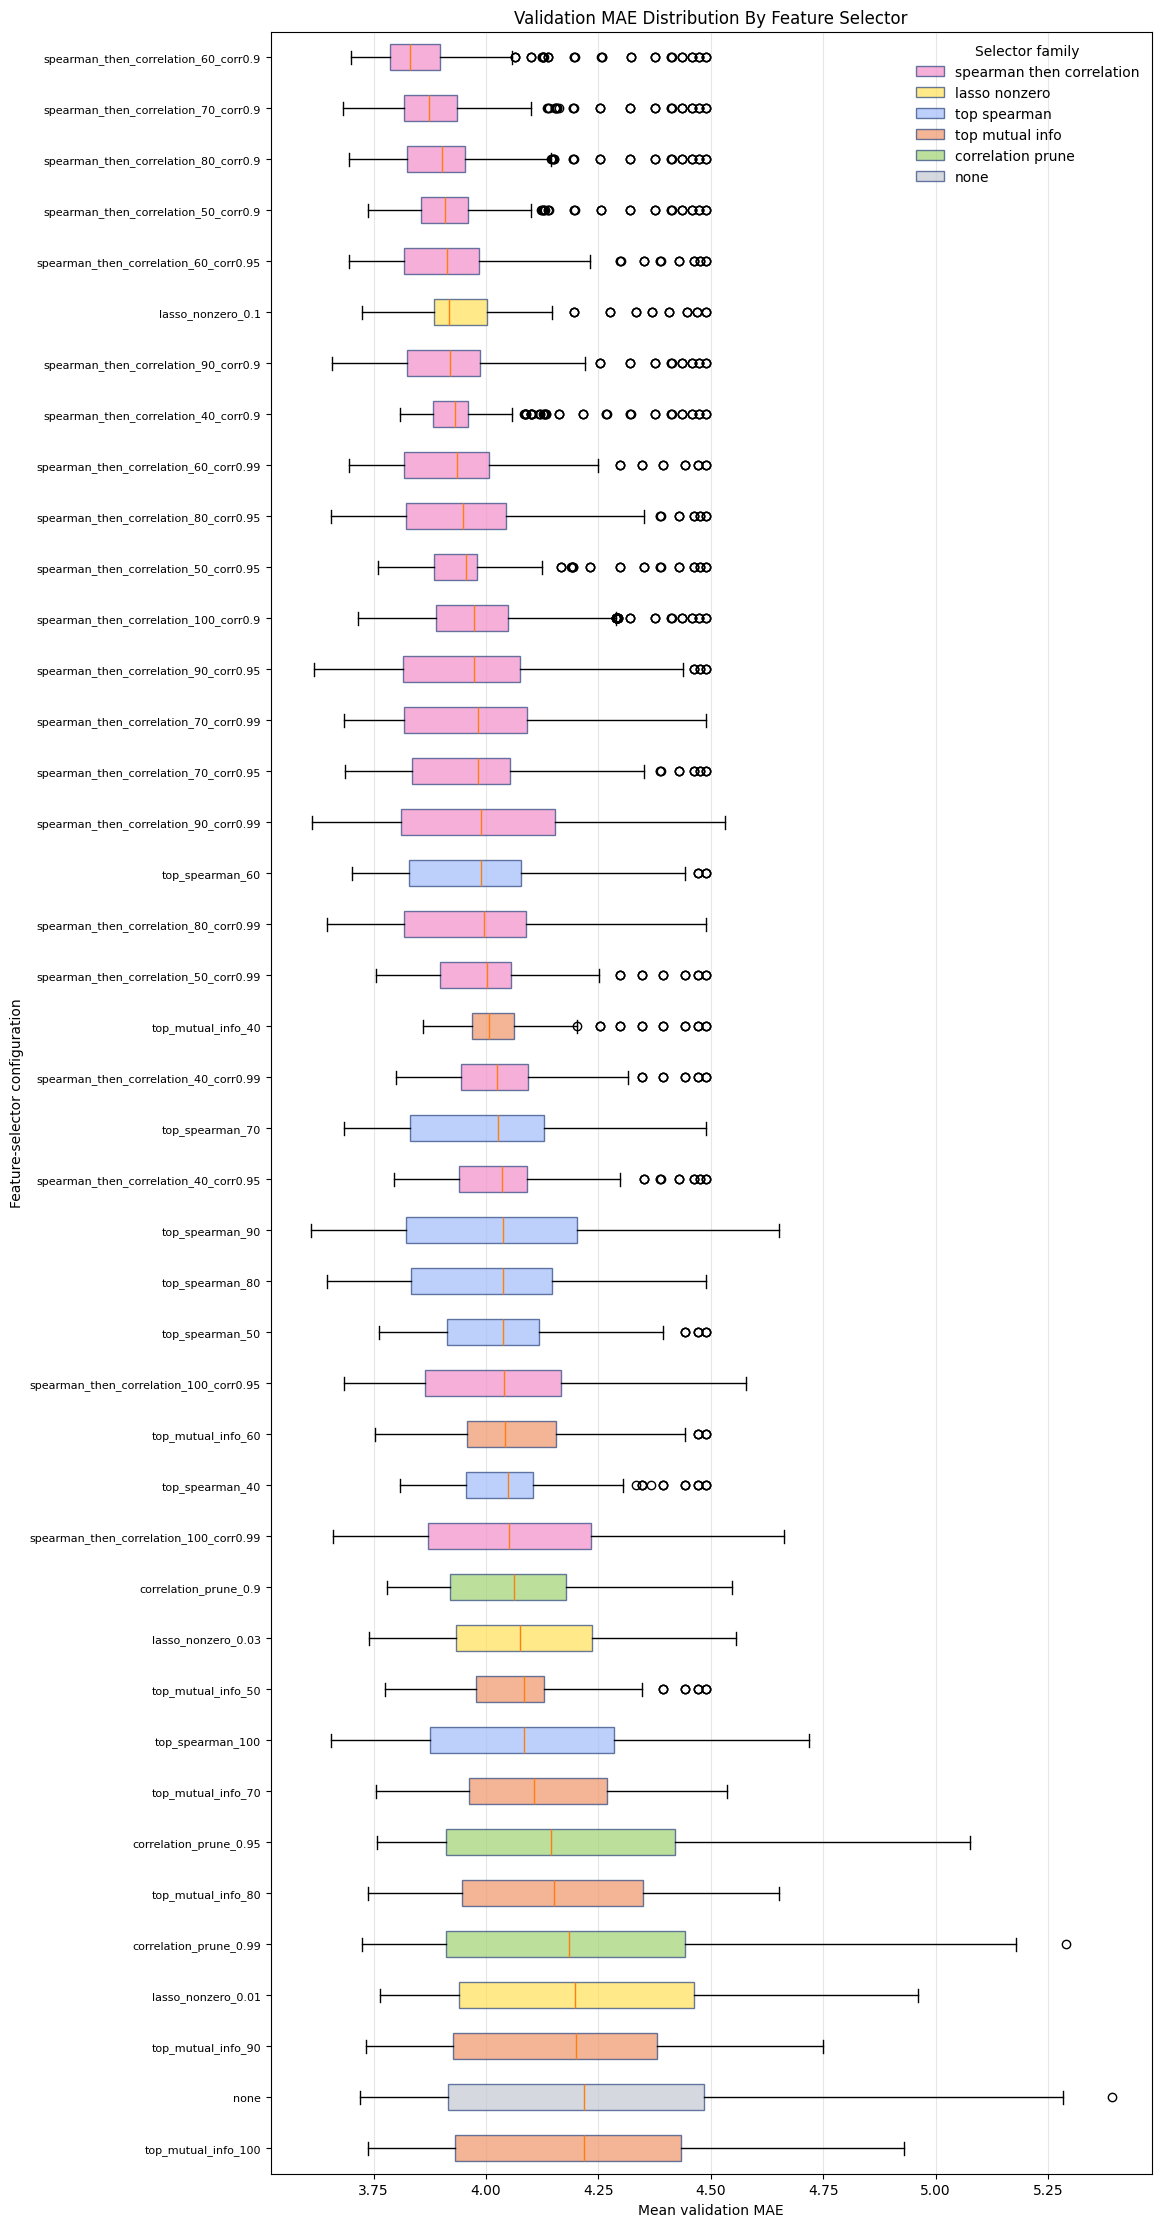

hyperparameter: ridge


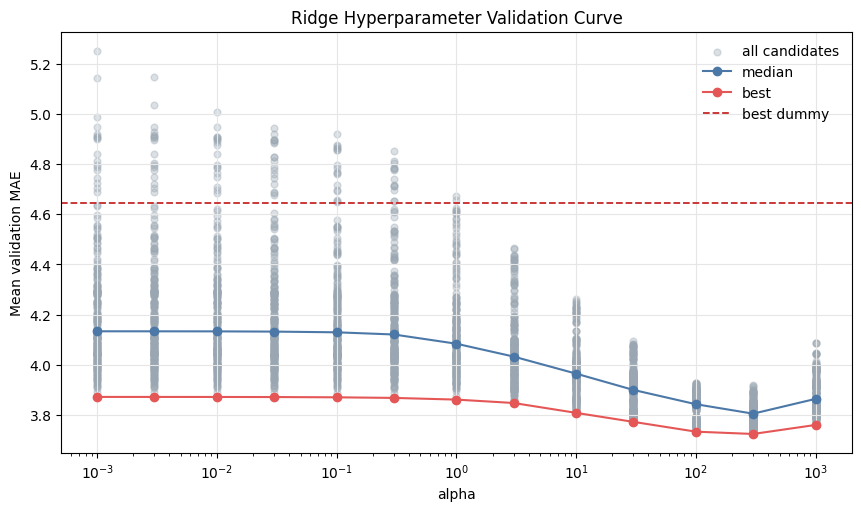

hyperparameter: lasso


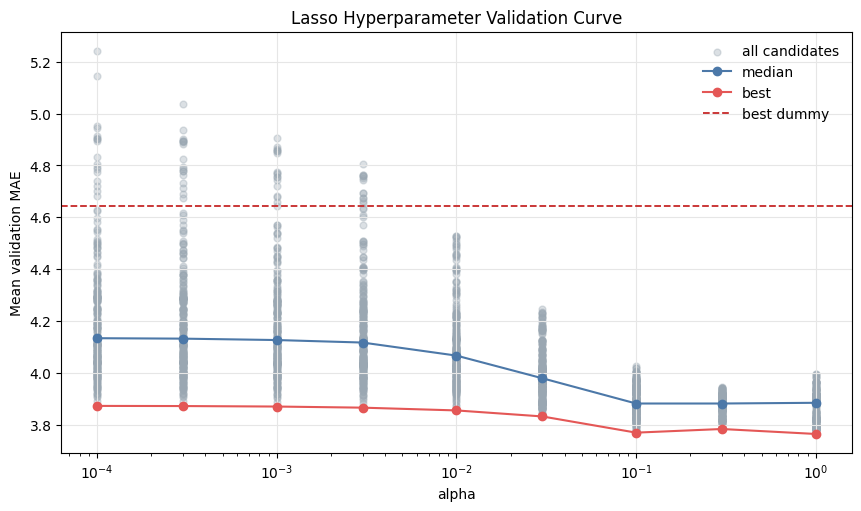

hyperparameter: pls


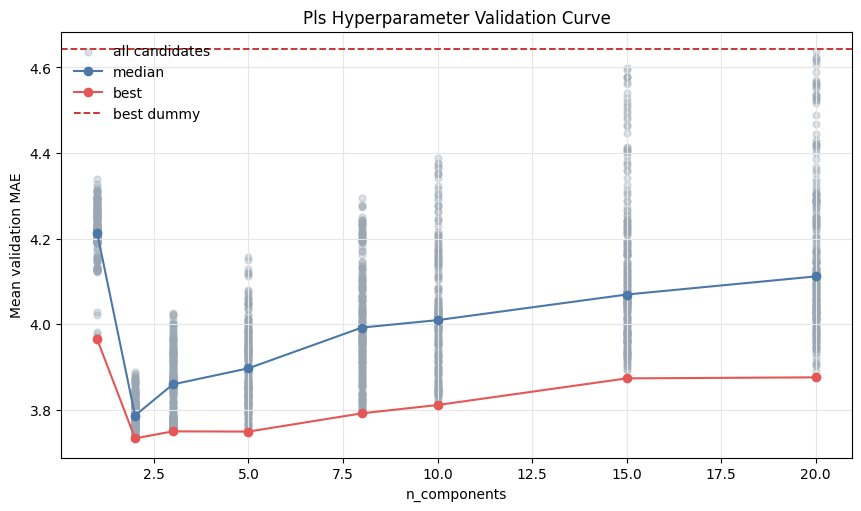

hyperparameter: elastic_net


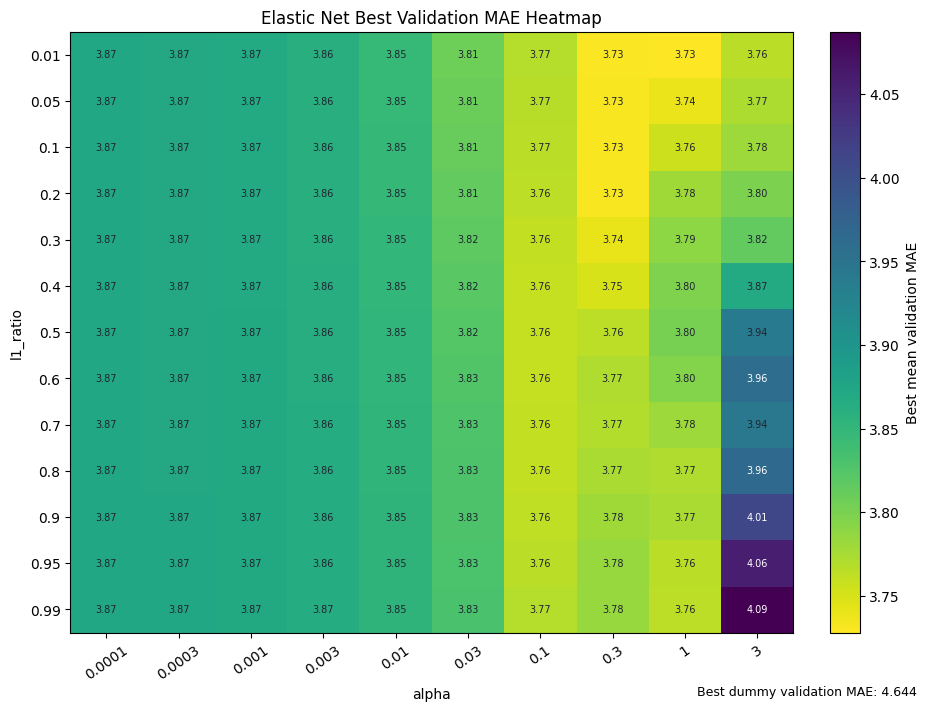

hyperparameter: huber


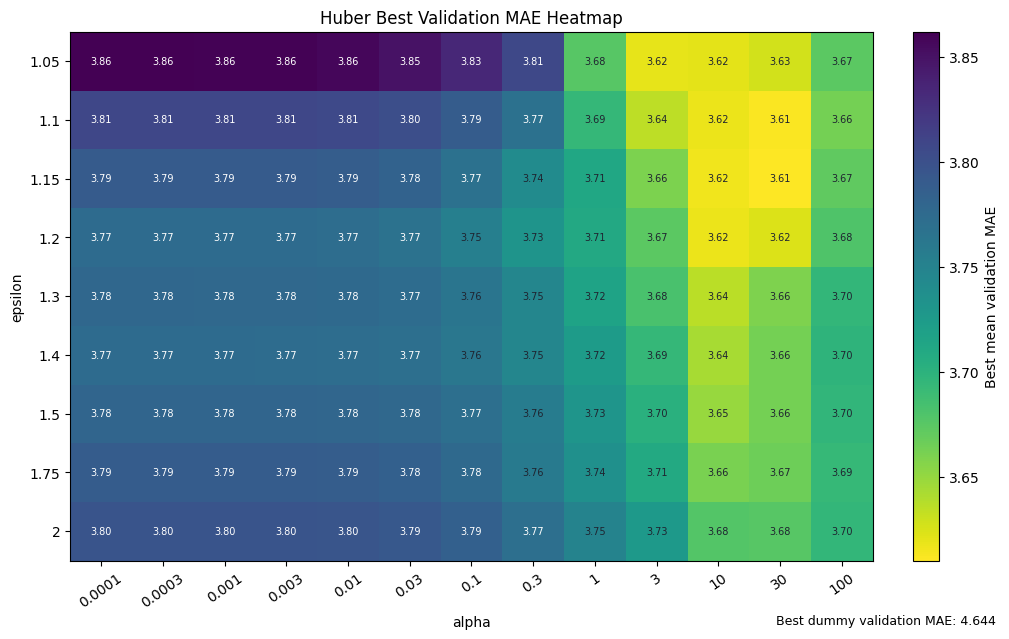

paired comparison: calibration_comparison


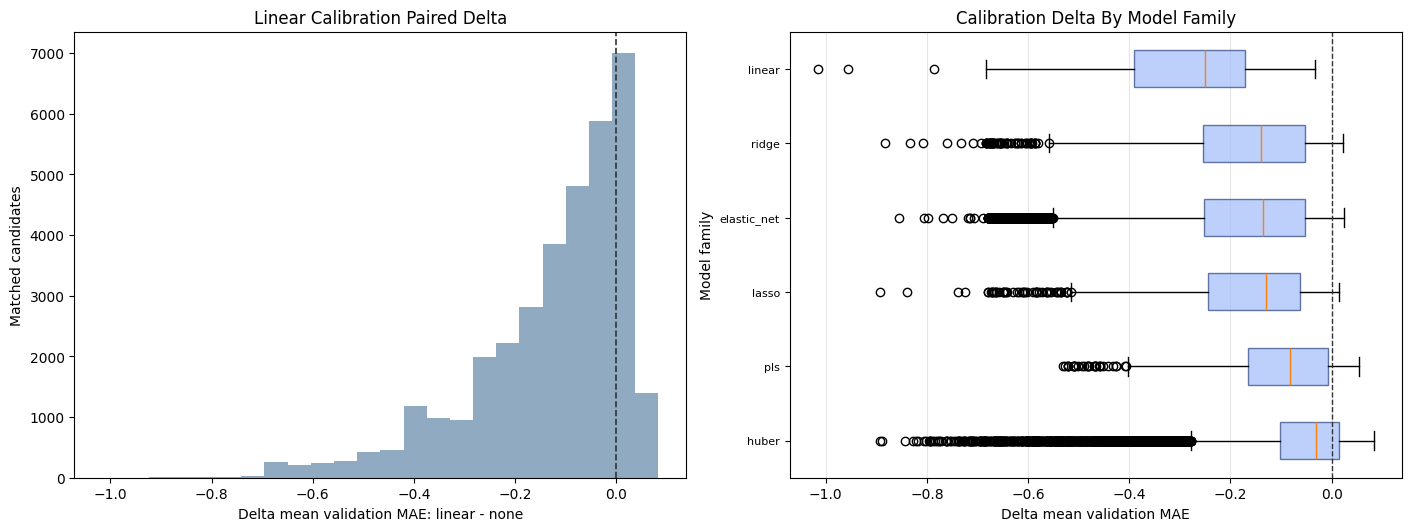

paired comparison: feature_selection_comparison


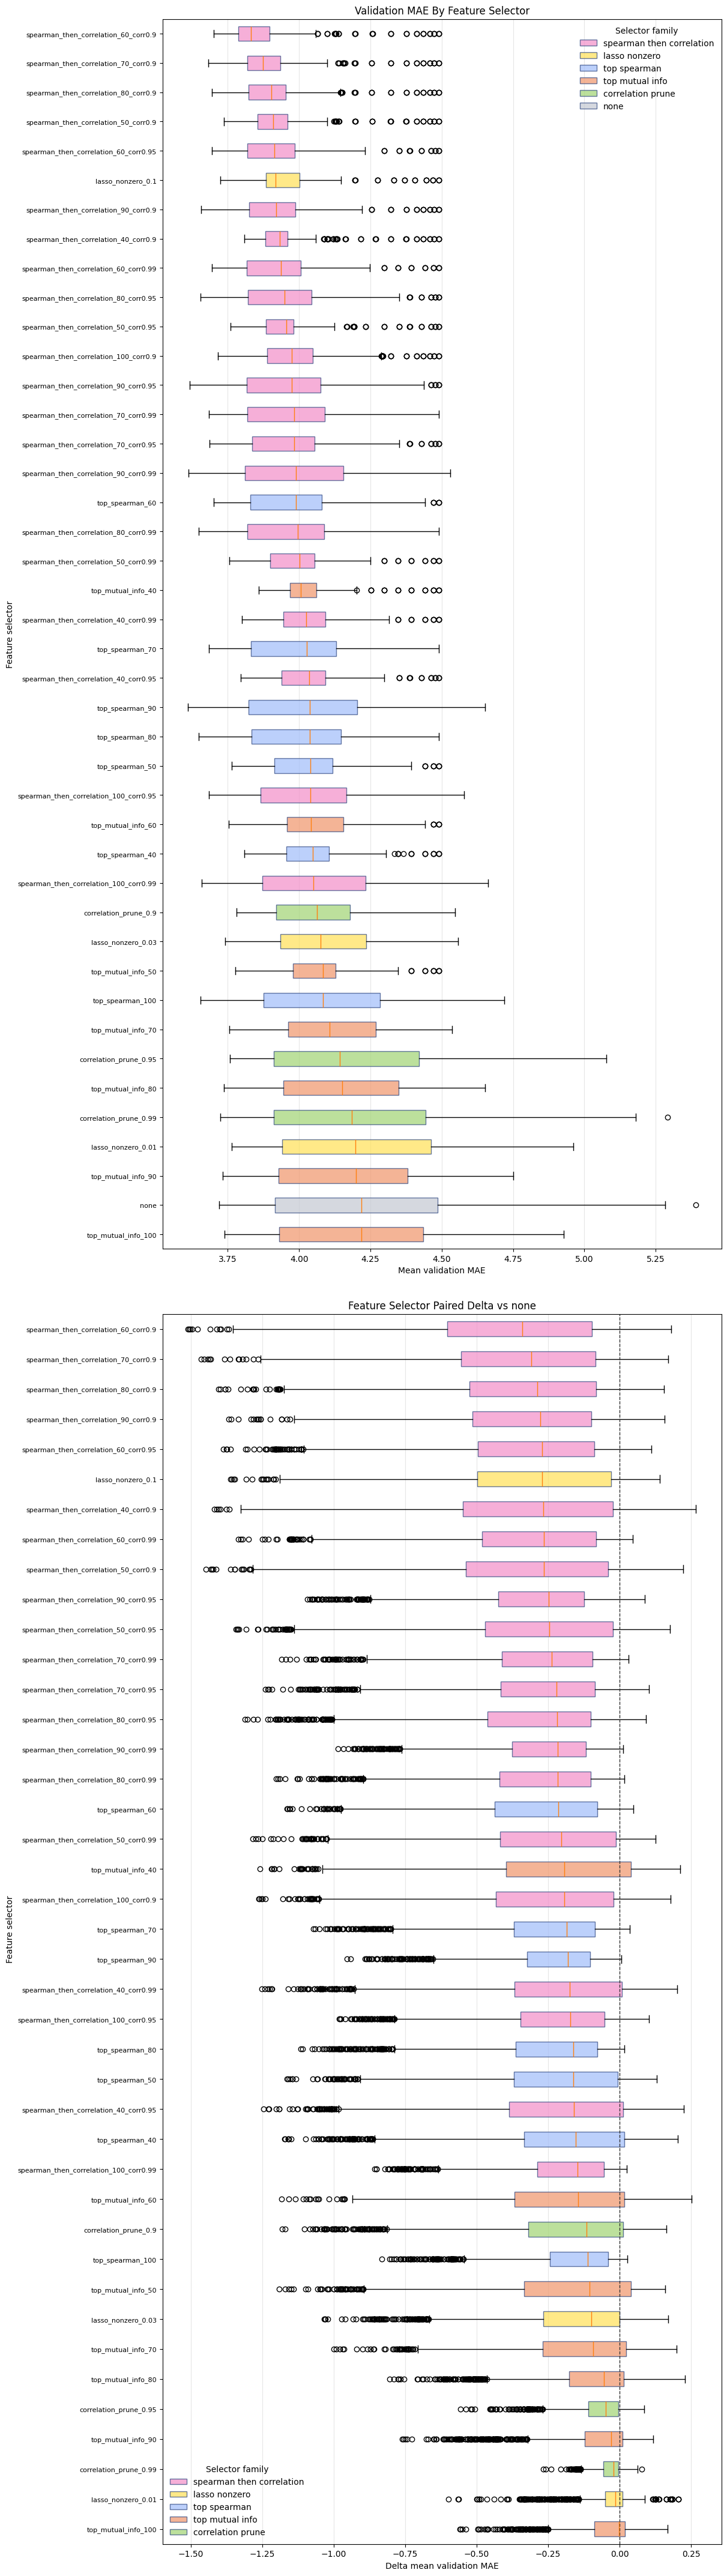

paired comparison: robust_clipping_comparison


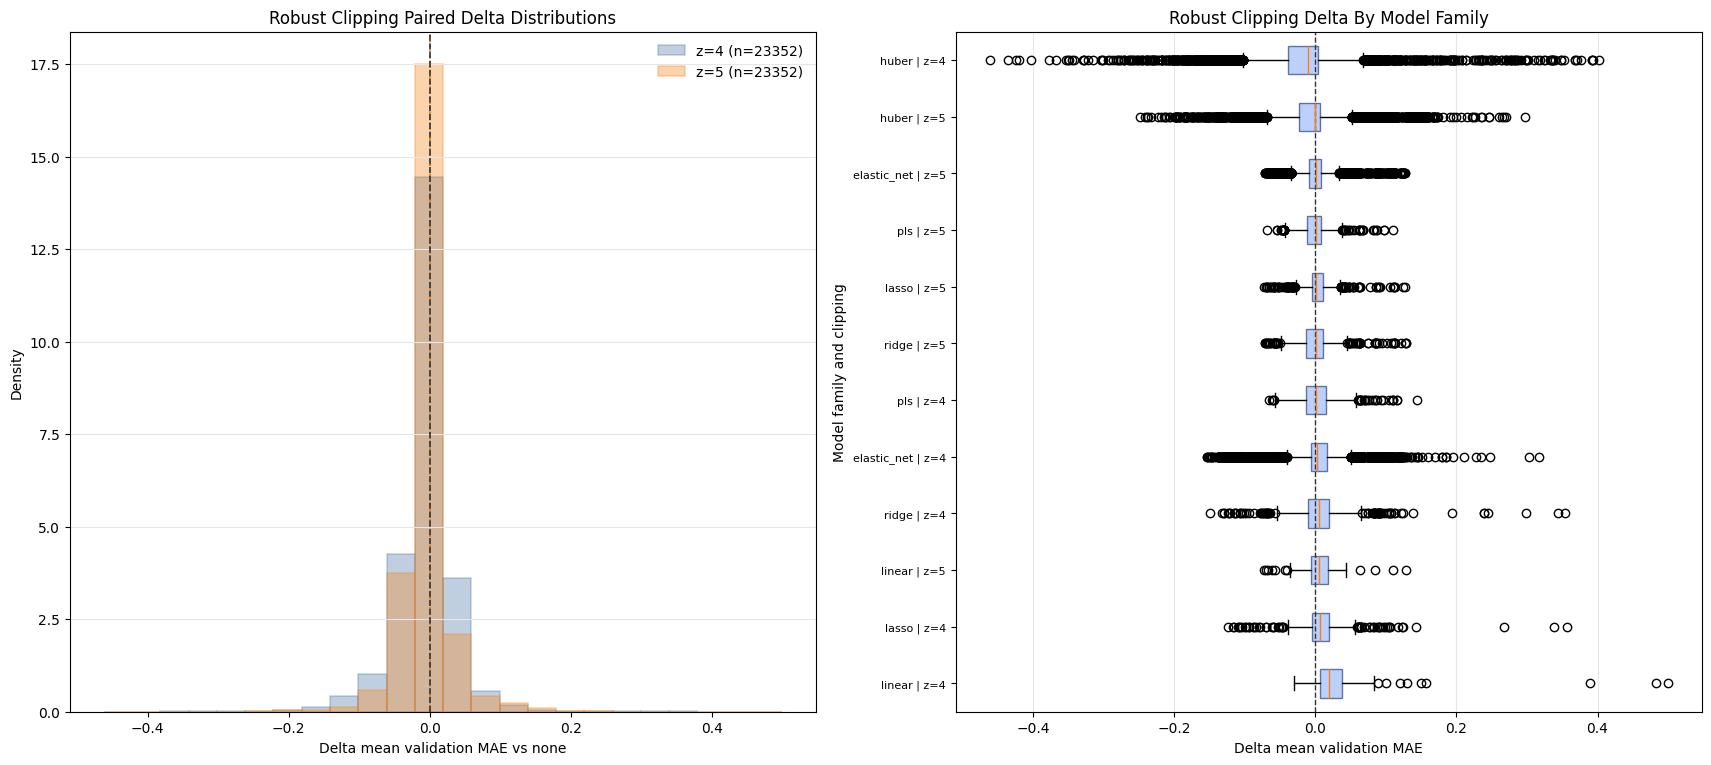

In [7]:
validation_figures = plot_stage4_linear_validation_diagnostics(
    tuning_result.tuning_summary,
    tuning_result.dummy_tuning_summary,
    top_n=25,
    top_per_model_family=TOP_CANDIDATES_PER_MODEL_FAMILY,
)
for figure_name, figure in validation_figures.items():
    print(figure_name)
    display(figure)
    plt.close(figure)

hyperparameter_figures = plot_stage4_linear_hyperparameter_diagnostics(
    tuning_result.tuning_summary,
    tuning_result.dummy_tuning_summary,
)
for figure_name, figure in hyperparameter_figures.items():
    print(f"hyperparameter: {figure_name}")
    display(figure)
    plt.close(figure)

factor_comparison_figures = plot_stage4_linear_factor_comparisons(
    tuning_result.tuning_summary,
)
for figure_name, figure in factor_comparison_figures.items():
    print(f"paired comparison: {figure_name}")
    display(figure)
    plt.close(figure)


## Refit Validation-Selected Finalists


In [8]:
result = finalize_stage4_linear_modeling(tuning_result)

print("Finalists refit on all pre-test rows; reserved future test evaluated once.")
display(
    pd.DataFrame(
        [
            {
                "validation_selected_finalists": len(result.model_selection_summary),
                "final_refit_rows": int(result.model_selection_summary["final_refit_rows"].max()),
                "future_test_evaluated": True,
            }
        ]
    )
)


Finalists refit on all pre-test rows; reserved future test evaluated once.


,validation_selected_finalists,final_refit_rows,future_test_evaluated
0,50,401,True


## Future Test Evaluation


In [9]:
future_test = result.leaderboard_slices["final_future_test"].sort_values("validation_selection_rank").reset_index(drop=True)
future_dummy = result.dummy_metrics.query("split == 'test'").sort_values("mae").reset_index(drop=True)

test_cols = [
    "validation_selection_rank",
    "model_kind",
    "feature_selection_mode",
    "robust_clip",
    "calibration",
    "mae",
    "rmse",
    "r2",
    "pearson",
    "spearman",
    "bias_pred_minus_target",
    "selected_feature_count_final_refit",
]
display(future_test[test_cols])
display(future_dummy[["model_kind", "baseline_value", "mae", "rmse", "r2", "bias_pred_minus_target"]])

rank1 = future_test.iloc[0]
best_dummy = future_dummy.iloc[0]
comparison = pd.DataFrame(
    [
        {
            "validation_selected_model": rank1["model_kind"],
            "validation_rank": int(rank1["validation_selection_rank"]),
            "model_test_mae": rank1["mae"],
            "best_dummy": best_dummy["model_kind"],
            "best_dummy_test_mae": best_dummy["mae"],
            "mae_delta_vs_best_dummy": best_dummy["mae"] - rank1["mae"],
            "mae_pct_delta_vs_best_dummy": 100.0 * (best_dummy["mae"] - rank1["mae"]) / best_dummy["mae"],
        }
    ]
)
display(comparison)


,validation_selection_rank,model_kind,feature_selection_mode,robust_clip,calibration,mae,rmse,r2,pearson,spearman,bias_pred_minus_target,selected_feature_count_final_refit
0,1,huber,top_spearman,z=4,linear,5.335537,8.736232,0.279234,0.571089,0.587631,-1.833487,90
1,2,huber,top_spearman,z=5,linear,5.342418,8.660144,0.291735,0.582434,0.581091,-1.808656,90
2,3,huber,top_spearman,z=4,linear,5.319827,8.716227,0.282532,0.574459,0.593197,-1.818979,90
3,4,huber,spearman_then_correlation,z=4,linear,5.317502,8.711251,0.283351,0.575583,0.586122,-1.834586,85
4,5,huber,spearman_then_correlation,z=4,none,5.276400,8.944957,0.244382,0.565756,0.611943,-2.309477,85
5,6,huber,spearman_then_correlation,z=5,linear,5.322165,8.645930,0.294058,0.585610,0.581745,-1.818608,85
6,7,huber,top_spearman,z=5,linear,5.322705,8.640676,0.294916,0.585888,0.588905,-1.793949,90
7,8,huber,spearman_then_correlation,z=4,linear,5.300636,8.690476,0.286765,0.578815,0.593700,-1.825190,85
8,9,huber,spearman_then_correlation,z=4,none,5.297128,8.957524,0.242258,0.560222,0.595863,-2.273901,69
9,10,huber,spearman_then_correlation,none,none,5.286779,8.725804,0.280954,0.597498,0.601933,-2.133042,85


,model_kind,baseline_value,mae,rmse,r2,bias_pred_minus_target
0,dummy_mean,16.161297,6.198213,10.615176,-0.064143,-2.606168
1,dummy_median,15.580000,6.326338,10.772640,-0.095948,-3.187465
2,dummy_last,14.380000,6.689155,11.186585,-0.181791,-4.387465


,validation_selected_model,validation_rank,model_test_mae,best_dummy,best_dummy_test_mae,mae_delta_vs_best_dummy,mae_pct_delta_vs_best_dummy
0,huber,1,5.335537,dummy_mean,6.198213,0.862676,13.918143


## Post-Refit Train, Validation, And Test Diagnostic

This plot includes the reserved future test only after validation-based finalist selection and refit. Test performance is diagnostic and is not used to choose models.


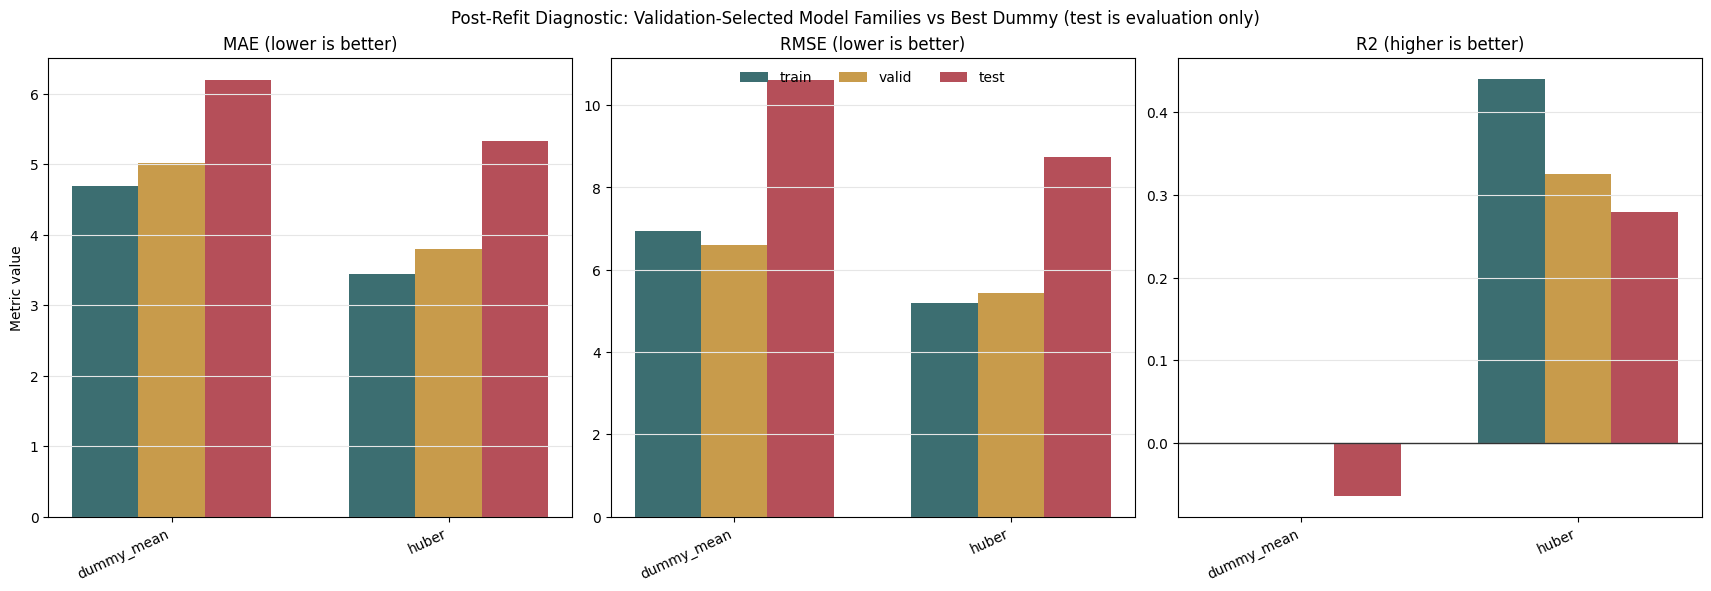

In [10]:
finalist_metric_fig = plot_stage4_linear_finalist_metric_comparison(
    result.final_metrics,
    result.dummy_metrics,
)
display(finalist_metric_fig)
plt.close(finalist_metric_fig)


## Prediction Diagnostics


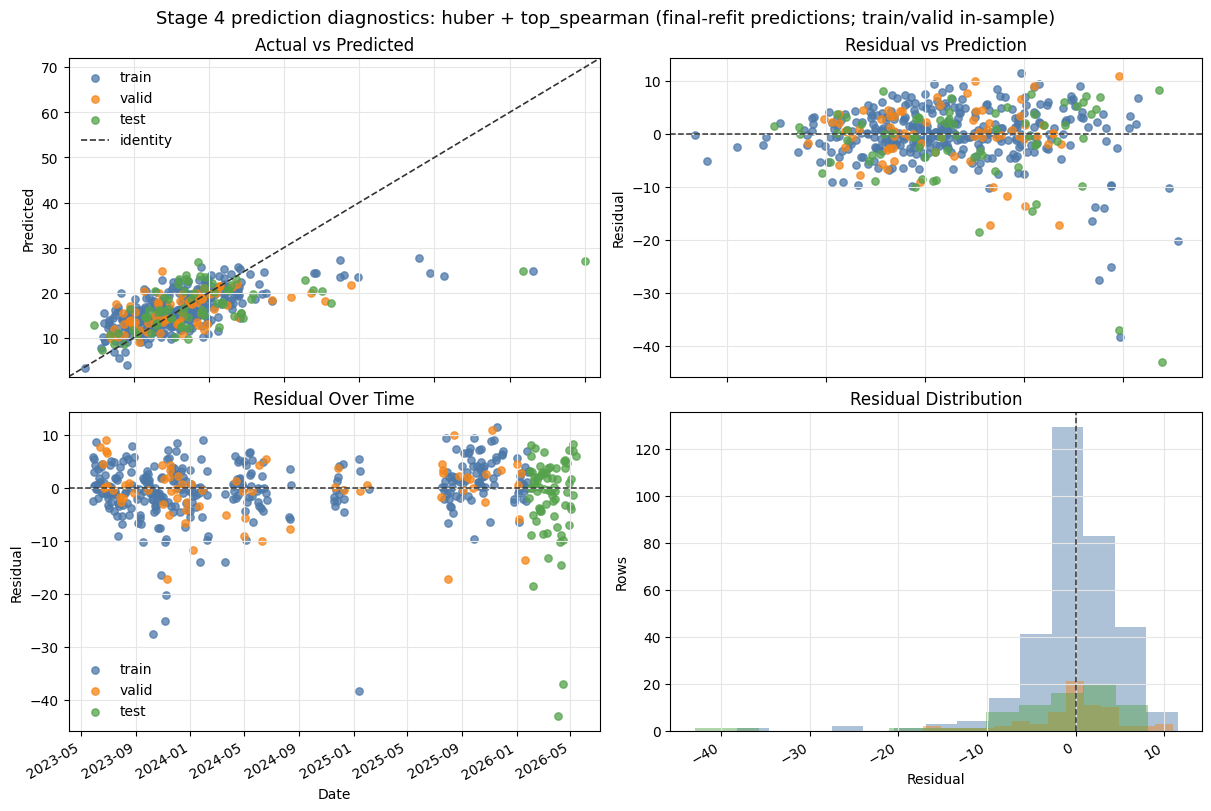

diagnostic_figure: /Users/abatrakov/Documents/FUN/wearable-analytics/docs/img/stage4_linear_prediction_diagnostics.png


In [11]:
diagnostic_fig = plot_stage4_linear_prediction_diagnostics(
    result.final_predictions,
    target_col=TARGET_COL,
    validation_selection_rank=1,
    splits=("train", "valid", "test"),
    save_path=diagnostic_figure_path,
)
display(diagnostic_fig)
plt.close(diagnostic_fig)
print("diagnostic_figure:", diagnostic_figure_path)


## Rank-1 Feature Importance Diagnostics

The feature-importance artifact focuses on the validation-selected rank-1 linear-family model. Coefficients are from the final refit on pre-test history; permutation importance is computed by fitting on train rows and evaluating on validation rows. The future test block is not used for this diagnostic.

![Rank-1 feature importance](../docs/img/stage4_linear_feature_importance.png)


In [ ]:
rank1_record = (
    result.leaderboard.loc[result.leaderboard["candidate_type"].eq("linear_family")]
    .sort_values("selection_rank")
    .iloc[0]
    .to_dict()
)
rank1_candidate = stage4_linear_candidate_from_record(rank1_record)
rank1_feature_importance = compute_stage4_linear_feature_importance(
    tuning_result.splits,
    tuning_result.feature_columns,
    rank1_candidate,
    config=config,
    permutation_repeats=10,
    random_state=REPEATED_HOLDOUT_SEED,
)
rank1_feature_importance.to_csv(feature_importance_path, index=False)
importance_fig = plot_stage4_linear_rank1_feature_importance(
    rank1_feature_importance,
    top_n=20,
    save_path=feature_importance_figure_path,
)
display(importance_fig)
plt.close(importance_fig)
display(rank1_feature_importance.head(20))
print("feature_importance:", feature_importance_path)
print("feature_importance_figure:", feature_importance_figure_path)


## Public Artifacts


In [12]:
summary_text = build_stage4_linear_summary_markdown(result)
summary_path.write_text(summary_text, encoding="utf-8")
result.leaderboard.to_csv(leaderboard_path, index=False)
result.candidate_grid.to_csv(grid_path, index=False)

best_by_model_family = build_stage4_linear_best_by_model_family_artifact(
    result.leaderboard_slices["best_by_model_kind"],
    result.leaderboard_slices["dummy_baselines"],
    result.leaderboard,
)
best_by_model_family.to_csv(best_by_model_family_path, index=False)

print("summary:", summary_path)
print("leaderboard:", leaderboard_path)
print("grid:", grid_path)
print("best_by_model_family:", best_by_model_family_path)
print("feature_importance:", feature_importance_path)
print("diagnostic_figure:", diagnostic_figure_path)
print("feature_importance_figure:", feature_importance_figure_path)


summary: /Users/abatrakov/Documents/FUN/wearable-analytics/reports/stage4_sleep_stress_linear_models_summary.md
leaderboard: /Users/abatrakov/Documents/FUN/wearable-analytics/reports/stage4_sleep_stress_linear_model_leaderboard.csv
grid: /Users/abatrakov/Documents/FUN/wearable-analytics/reports/stage4_sleep_stress_linear_model_grid.csv
best_by_model_family: /Users/abatrakov/Documents/FUN/wearable-analytics/reports/stage4_sleep_stress_linear_best_by_model_family.csv
feature_importance: /Users/abatrakov/Documents/FUN/wearable-analytics/reports/stage4_sleep_stress_linear_rank1_feature_importance.csv
diagnostic_figure: /Users/abatrakov/Documents/FUN/wearable-analytics/docs/img/stage4_linear_prediction_diagnostics.png
feature_importance_figure: /Users/abatrakov/Documents/FUN/wearable-analytics/docs/img/stage4_linear_feature_importance.png


## Final Read

This pass tested whether linear-family regressions can predict next-sleep average stress from the Stage 4 day-to-next-sleep monitoring frame. The best validation-selected model in the expanded run was a Huber regressor with `alpha=30`, `epsilon=1.15`, `top_spearman_90` feature selection, `z=4` robust clipping, and linear calibration.

On the reserved future block, that validation rank-1 model reached MAE `5.336`, improving by `0.863` points (`13.9%`) versus the best dummy baseline. The diagnostic plots suggest a real but modest signal: recent wake/pre-sleep stress and heart-rate variability features carry much of the linear association, while the future block still shows drift and extreme-night underprediction.

The grid analysis makes Huber-style robust regression a strong linear baseline, with feature-selection, clipping, and calibration choices worth tuning explicitly. The next modeling step is tree ensembles, because the linear family may be compressing nonlinear or threshold-like physiology patterns that are visible in the residual diagnostics.
